In [ ]:
from datasets import load_dataset

In [6]:
ds = load_dataset("imdb")

In [7]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [8]:
train_df = ds['train'].to_pandas()

In [9]:
train_df

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0
...,...,...
24995,A hit at the time but now better categorised a...,1
24996,I love this movie like no other. Another time ...,1
24997,This film and it's sequel Barry Mckenzie holds...,1
24998,'The Adventures Of Barry McKenzie' started lif...,1


In [10]:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [11]:
import numpy as np
train_df['sentiment'] = np.where(train_df['label'] == 0, 'negative', 'positive')

In [12]:
train_df

,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative
2,If only to avoid making this type of film in t...,0,negative
3,This film was probably inspired by Godard's Ma...,0,negative
4,"Oh, brother...after hearing about this ridicul...",0,negative
...,...,...,...
24995,A hit at the time but now better categorised a...,1,positive
24996,I love this movie like no other. Another time ...,1,positive
24997,This film and it's sequel Barry Mckenzie holds...,1,positive
24998,'The Adventures Of Barry McKenzie' started lif...,1,positive


In [13]:
train_df['sentiment'].value_counts()

sentiment
negative    12500
positive    12500
Name: count, dtype: int64

<Axes: >

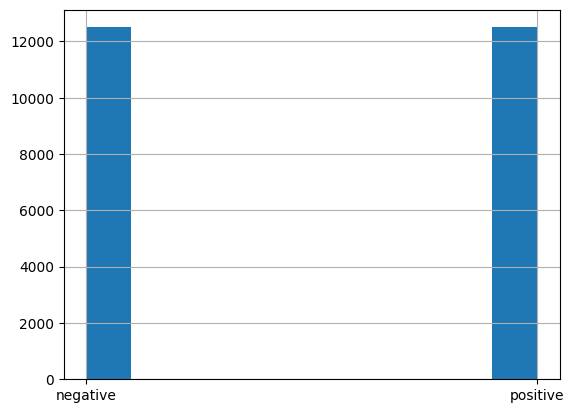

In [14]:
import matplotlib.pyplot as plt

train_df.sentiment.hist()

In [15]:
from sklearn.model_selection import train_test_split

In [19]:
examples_df, gold_examples_df = train_test_split(train_df, test_size=0.2, random_state=42)

In [20]:
examples_df.shape, gold_examples_df.shape

((20000, 3), (5000, 3))

In [21]:
cols = ['text', 'sentiment']
gold_examples = gold_examples_df[cols].sample(20, random_state=42).to_dict(orient='records')

In [22]:
gold_examples

[{'text': 'Like I said at the top, four stars just aren\'t enough. It\'s one of the best films I\'ve ever seen in my almost 17 years of life. For the people that don\'t really like it or understand it, you must not have a real appreciation for art or you might have a short attention span.<br /><br />Even if I haven\'t seen all his films yet, I\'d have to say that this is Spielberg at his peak. It\'s pretty sad to see that movies as great as "The Color Purple" don\'t come along too often \'cause I think all of us are in desperate need of first-class motion picture entertainment in these hard times.<br /><br />Movies like this are more than just movies; they\'re pieces of art that need to be appreciated more.<br /><br />The idea that it was nominated for 11 Oscars (even Best Picture of the Year) and didn\'t get one trophy is a sign of how blind and stupid Hollywood can be sometimes. Spielberg wasn\'t even nominated for Best Director! It should have swept the Oscars that year.<br /><br />

In [26]:
user_prompt_template = """ ```{movie_review}``` """

In [27]:
zero_shot_prompt_sys= """Classify the sentiment of the movie reviews presented in the input as positive or negative>
Movies reviews will be delimited by triple backticks ``` in the input. Answers only as positive or negative. Don t explain your answer."""

In [28]:
zero_shot_prompt = [{"role" : "system", "content" : zero_shot_prompt_sys}]

In [30]:
few_shot_prompt_system = """Classify the sentiment of the movie reviews presented in the input as positive or negative>
Movies reviews will be delimited by triple backticks ``` in the input. Answers only as positive or negative. Don t explain your answer."""

In [83]:
positive_reviews = examples_df[cols][examples_df['sentiment']== 'positive'].sample(4)

In [84]:
negative_reviews = examples_df[cols][examples_df['sentiment'] == 'negative'].sample(4)

In [85]:
positive_reviews.shape, negative_reviews.shape

((4, 2), (4, 2))

In [86]:
negative_reviews

,text,sentiment
5288,It's been a looooonnnggg time since I saw this...,negative
11245,This move was on TV last night. I guess as a t...,negative
6359,Over the last 20 years the majority of British...,negative
12300,ANDY HARDY MEETS DEBUTANTE (1940) is the ninth...,negative


In [87]:
positive_reviews

,text,sentiment
24113,I don't think I've really ever given Walter Ma...,positive
24043,"Red Eye, a movie that id had wanted to see for...",positive
15018,"When I first read Hamlet, I couldn't help but ...",positive
19649,"Just after I saw the movie, the true magic fee...",positive


In [88]:
positive_examples = positive_reviews[cols].sample(4, random_state=42).to_dict(orient='records')

In [89]:
negative_examples = negative_reviews[cols].sample(4, random_state=42).to_dict(orient='records')

In [90]:
positive_examples

[{'text': 'Red Eye, a movie that id had wanted to see for awhile...Cillian Murphy plays Jack Ripner (jack the ripper) a managerial pose to Assassins, and his literally killer plan to knock off a highly profiled man and his family.<br /><br />An everyday woman "Lisa" (I think) is a normal woman, goes to work, home...worries...hates to fly.<br /><br />The death of her grandmother sends her on a flight which delayed several times.<br /><br />a flight where she meets Jack...an ordinary seeming guy, until he suavely reveals his profession and plans, which coincidentally include her in them, she is the key to the Keefe\'s (sp?) death.<br /><br />She succeeds in saving them...but nearly the cost of her life is taken, Jack is beaten...the Keefs are saved...oh what a story *laughs* just kidding, the movie is really good actually, the best of last year...there are small things that you have to pay attention to earlier in the movie that play a GREAT importance to the movie later... (the Frankenst

In [91]:
negative_examples

[{'text': 'This move was on TV last night. I guess as a time filler, because it sucked bad! The movie is just an excuse to show some tits and ass at the start and somewhere about half way. (Not bad tits and ass though). But the story is too ridiculous for words. The "wolf", if that is what you can call it, is hardly shown fully save his teeth. When it is fully in view, you can clearly see they had some interns working on the CGI, because the wolf runs like he\'s running in a treadmill, and the CGI fur looks like it\'s been waxed, all shiny :)<br /><br />The movie is full of gore and blood, and you can easily spot who is going to get killed/slashed/eaten next. Even if you like these kind of splatter movies you will be disappointed, they didn\'t do a good job at it.<br /><br />Don\'t even get me started on the actors... Very corny lines and the girls scream at everything about every 5 seconds. But then again, if someone asked me to do bad acting just to give me a few bucks, then hey, whe

In [92]:
import pandas as pd

In [93]:
examples = pd.concat([positive_reviews, negative_reviews]).sample(8, replace=False).to_dict(orient='records')

In [94]:
examples

[{'text': 'This move was on TV last night. I guess as a time filler, because it sucked bad! The movie is just an excuse to show some tits and ass at the start and somewhere about half way. (Not bad tits and ass though). But the story is too ridiculous for words. The "wolf", if that is what you can call it, is hardly shown fully save his teeth. When it is fully in view, you can clearly see they had some interns working on the CGI, because the wolf runs like he\'s running in a treadmill, and the CGI fur looks like it\'s been waxed, all shiny :)<br /><br />The movie is full of gore and blood, and you can easily spot who is going to get killed/slashed/eaten next. Even if you like these kind of splatter movies you will be disappointed, they didn\'t do a good job at it.<br /><br />Don\'t even get me started on the actors... Very corny lines and the girls scream at everything about every 5 seconds. But then again, if someone asked me to do bad acting just to give me a few bucks, then hey, whe

In [95]:
def create_examples(dataset, n=4):
    positive_reviews =dataset[cols][dataset['sentiment'] == 'positive'].sample(n)
    negative_reviews = dataset[cols][dataset['sentiment'] == 'negative'].sample(n)
    examples = pd.concat([positive_reviews, negative_reviews]).sample(2*n, replace=False).to_dict(orient='records')
    return examples

In [99]:
examples = create_examples(examples_df, n=6)

In [100]:
examples

[{'text': 'Louis Creed, a doctor from Chicago, moves to a large house near a small town, since he is going to be giving classes in the University of Maine\'s. Along with him, is his wife Rachel and their two kids, Ellie and Gage,as well as Ellie\'s cat, Church. Soon, they met their new neighbor,and old man named Judd Crandall.Judd not only warns Louis and Rachel about the danger that is the highway that runs past their house(that is constantly a way used by big trucks) but also show to the family a pet cemetery that is located near their house. Judd starts to talk about the importance of the pet cemetery, but Rachel is against to talk about death and spirituality with her children, since she has traumas from her sister Zelda\'s death.<br /><br />During the first week of the family in the new house, Louis already has dead people to deal with: Victor Pascow, a student who has been fatally injured in an automobile accident, addresses his dying words to Louis personally, even though the tw